In [1]:
import numpy as np
import pandas as pd

# model
from sklearn.ensemble import AdaBoostClassifier

# base model used by AdaBoost
from sklearn.tree import DecisionTreeClassifier

# splitting dataset
from sklearn.model_selection import train_test_split

# hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score

# visualization
import matplotlib.pyplot as plt

# curves
from sklearn.model_selection import learning_curve
from sklearn.model_selection import validation_curve

In [2]:
df = pd.read_excel("C:/Users/NITIKA KUMARI/Downloads/Influenza_surveillance_Data.xlsx")

In [3]:
df.columns

Index(['Pathogen Test Result', 'Host Sex', 'Host Age', 'diarrhea', 'cough',
       'running nose', 'myalgia', 'short breath', 'nausea', 'headache',
       'malaise', 'throat', 'fever',
       'Acquired absence of right and left ankle', 'TB', 'hyperlipidemia',
       'Recurrent Otitis Media', 'acid reflux', 'glaucoma', 'Asthma', 'Cancer',
       'Cardiovascular_disease', 'hematological_disease', 'migraines_updated',
       'neurologic_disorder', 'Obesity', 'hepatobiliary_disease',
       'respiratory_disease', 'urogenital_disease', 'Other_Chronic_Conditions',
       'Allergies', 'chronic_lung_disease', 'Immunosuppression',
       'autoimmune_disorder', 'endocrine_metabolic_disorder'],
      dtype='object')

In [4]:
# Target
y = df['Pathogen Test Result']

# Features (drop target)
X = df.drop('Pathogen Test Result', axis=1)

In [5]:
X = X.replace({'Yes':1, 'No':0})

In [6]:
X = pd.get_dummies(X, drop_first=True)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y
)

In [8]:
# base estimator (weak learner)
base_model = DecisionTreeClassifier(max_depth=1)

# AdaBoost model
ada = AdaBoostClassifier(

    estimator = base_model,

    random_state = 42

)

In [9]:
param_grid = {

    'n_estimators': [50,100,200,300],

    'learning_rate': [0.01,0.1,0.5,1]

}

In [10]:
grid = GridSearchCV(

    estimator = ada,       # AdaBoost model

    param_grid = param_grid,

    cv = 5,                # 5-fold cross validation

    scoring = 'accuracy',  # optimization metric

    n_jobs = -1            # use all CPU cores

)

grid.fit(X_train, y_train)

,estimator,AdaBoostClass...ndom_state=42)
,param_grid,"{'learning_rate': [0.01, 0.1, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [11]:
#Best Model
best_ada = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'learning_rate': 1, 'n_estimators': 300}


In [12]:
#Predictions
# predicted class labels
y_pred = best_ada.predict(X_test)

# probability predictions
y_prob = best_ada.predict_proba(X_test)[:,1]

In [13]:
#Accuracy & Precision
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("Precision:", precision)

Accuracy: 0.693135935397039
Precision: 0.6696562032884903


In [14]:
#TNR / Specificity
cm = confusion_matrix(y_test, y_pred)

TN = cm[0,0]

FP = cm[0,1]

specificity = TN / (TN + FP)

print("Specificity (TNR):", specificity)

Specificity (TNR): 0.7247820672478207


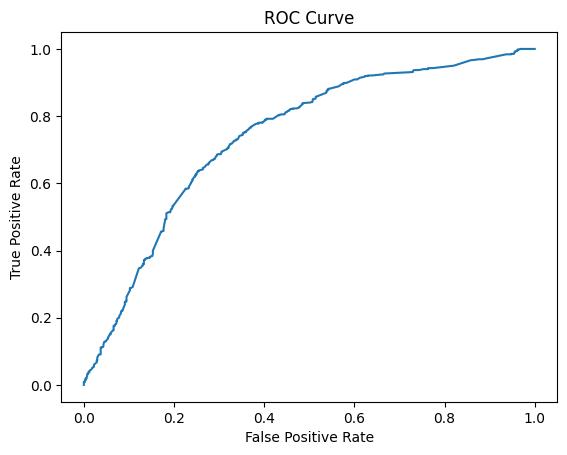

In [15]:
#ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

In [16]:
#AUC Score
auc = roc_auc_score(y_test, y_prob)

print("AUC:", auc)

AUC: 0.7399010664619682


In [17]:
#Feature Importance
importances = best_ada.feature_importances_

features = X.columns

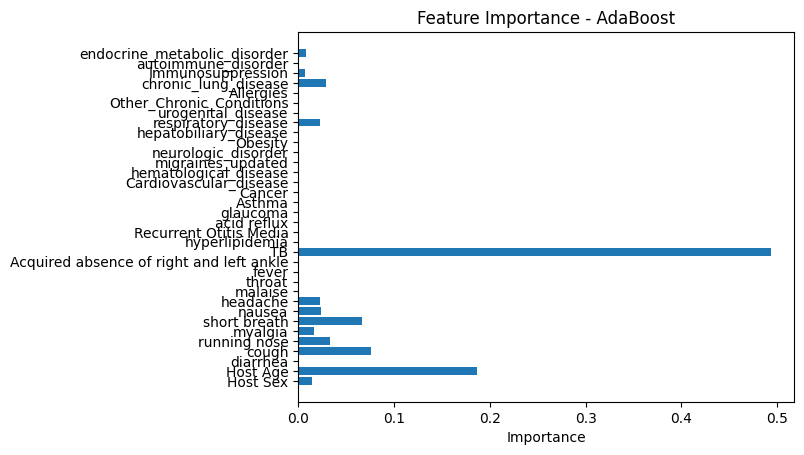

In [18]:
#Plot Feature Importance
plt.barh(features, importances)

plt.xlabel("Importance")

plt.title("Feature Importance - AdaBoost")

plt.show()

In [19]:
#Learning Curve
train_sizes, train_scores, test_scores = learning_curve(

    best_ada,

    X,

    y,

    cv=5,

    scoring='accuracy',

    train_sizes=np.linspace(0.1,1.0,5)

)

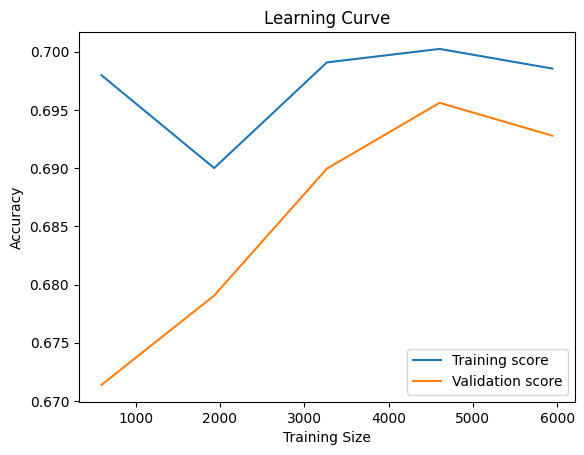

In [20]:
#Plot Learning Curve
train_mean = np.mean(train_scores, axis=1)

test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label="Training score")

plt.plot(train_sizes, test_mean, label="Validation score")

plt.xlabel("Training Size")

plt.ylabel("Accuracy")

plt.title("Learning Curve")

plt.legend()

plt.show()

In [21]:
#Validation Curve
param_range = [50,100,200,300,400]

train_scores, test_scores = validation_curve(

    AdaBoostClassifier(),

    X,

    y,

    param_name="n_estimators",

    param_range=param_range,

    cv=5,

    scoring="accuracy"

)

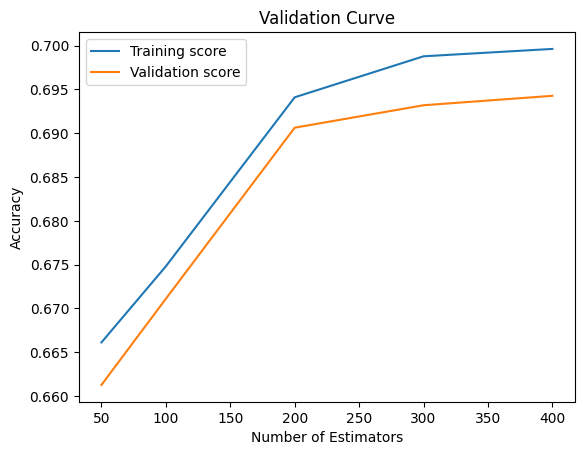

In [22]:
#Plot Validation Curve
train_mean = np.mean(train_scores, axis=1)

test_mean = np.mean(test_scores, axis=1)

plt.plot(param_range, train_mean, label="Training score")

plt.plot(param_range, test_mean, label="Validation score")

plt.xlabel("Number of Estimators")

plt.ylabel("Accuracy")

plt.title("Validation Curve")

plt.legend()

plt.show()